<div class="xgb-config">
  <h3>XGBoost with Pseudo-Labels (RAPIDS cuDF)</h3>
  
  <div class="section">
    <label>Dataset: <select><option>Competition Dataset</option></select></label>
    <label>Target: <input type="text" value="target"></label>
  </div>
  <div class="section">
    <label>Folds IN (train): <input type="text" value="0,1,2,3"></label>
    <label>Folds OUT (valid): <input type="text" value="4"></label>
  </div>
  <div class="section">
    <label>n_estimators: <input type="number" value="1000"></label>
    <label>max_depth: <input type="number" value="6"></label>
    <label>learning_rate: <input type="number" value="0.1" step="0.01"></label>
  </div>
  <div class="section">
    <label><input type="checkbox" checked> Enable Pseudo-Labels</label>
    <div class="pseudo">
      <label>Threshold: <input type="number" value="0.8" step="0.05"></label>
      <label>Max samples: <input type="number" value="1000"></label>
      <label>Weight: <input type="number" value="0.5" step="0.1"></label>
      <label>Encoder: <select><option>sklearn TargetEncoder</option></select></label>
    </div>
  </div>
  <div class="section">
    <label><input type="checkbox" checked> Save test preds per fold</label>
    <label><input type="checkbox" checked> Mean feature importance</label>
  </div>
  <button>Run XGB with Pseudo-Labels</button>
</div>

<style>
  .xgb-config {
    font-family: system-ui, sans-serif;
    max-width: 500px;
    padding: 20px;
    background: linear-gradient(135deg, #667eea, #764ba2);
    border-radius: 12px;
    color: white;
  }
  .section {
    background: rgba(255,255,255,0.95);
    color: #333;
    padding: 15px;
    margin: 10px 0;
    border-radius: 8px;
    display: flex;
    flex-wrap: wrap;
    gap: 10px;
  }
  label { display: flex; align-items: center; gap: 5px; font-size: 14px; }
  input, select { padding: 4px 8px; border: 1px solid #ddd; border-radius: 4px; }
  .pseudo { width: 100%; display: flex; flex-wrap: wrap; gap: 10px; margin-top: 10px; }
  button { 
    width: 100%; padding: 12px; background: #4CAF50; color: white; 
    border: none; border-radius: 6px; font-weight: bold; cursor: pointer;
  }
</style>

In [1]:
NAME = '001'

In [2]:
from sklearn.metrics import roc_auc_score, roc_curve, auc, RocCurveDisplay
from sklearn.model_selection import KFold
from sklearn.preprocessing import TargetEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
import seaborn as sns

In [3]:
# Remove or comment out the cudf.pandas line
# %load_ext cudf.pandas

import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 500)
pd.set_option('display.max_rows', 200)

In [4]:
train_file = '/kaggle/input/competitions/playground-series-s6e3/train.csv'
test_file = '/kaggle/input/competitions/playground-series-s6e3/test.csv'
original_file = '/kaggle/input/datasets/thedrzee/customer-churn-in-telecom-sample-dataset-by-ibm/WA_Fn-UseC_-Telco-Customer-Churn.csv'

train = pd.read_csv(train_file)
test = pd.read_csv(test_file)
orig = pd.read_csv(original_file)

train_ids = train['id'].copy()
test_ids = test['id'].copy() # for submission

In [5]:
train['Churn'] = train['Churn'].map({'No': 0, 'Yes': 1})
orig['Churn'] = orig['Churn'].map({'No': 0, 'Yes': 1})

In [6]:
test.columns.shape

(20,)

In [7]:
train.columns

Index(['id', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [8]:
CATS = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]
print(f"There are {len(CATS)} categorical columns:")
print(CATS)

NUMS = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(f"There are {len(NUMS)} numerical columns:")
print(NUMS)

There are 15 categorical columns:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
There are 3 numerical columns:
['tenure', 'MonthlyCharges', 'TotalCharges']


# Feature Engineering

In [9]:
NEW_NUMS = []
NEW_CATS = []
NUM_AS_CAT = []
TO_REMOVE = []
NON_TE_CATS = []

In [10]:
# Compute frequencies from ALL data (train + orig + test)
for cat in NUMS:
    freq = pd.concat([train[cat], orig[cat], test[cat]]).value_counts(normalize=True)
    for df in [train, test, orig]:
        df[f'FREQ_{cat}'] = df[cat].map(freq).fillna(0).astype('float32')
    NEW_NUMS.append(f'FREQ_{cat}')

In [11]:
# numerical as categorical
for col in NUMS:    
    _new_col = f'CAT_{col}'
    NUM_AS_CAT.append(_new_col)

    for df in [train, test, orig]:
        df[_new_col] = df[col].astype(str).astype('category')

In [12]:
train.isna().any().any(), test.isna().any().any()

(np.False_, np.False_)

In [13]:
# Debug: Check data types before merging
for col in CATS + NUMS + NEW_CATS:
    print(f"\nColumn: {col}")
    print(f"orig dtype: {orig[col].dtype}")
    if col in train.columns:
        print(f"train dtype: {train[col].dtype}")
    if col in test.columns:
        print(f"test dtype: {test[col].dtype}")
    
    tmp = orig.groupby(col)['Churn'].mean()
    tmp.name = (_new_col := f"ORIG_proba_{col}")
    tmp = tmp.reset_index()
    print(f"tmp dtype: {tmp[col].dtype}")
    
    # Now proceed with merging after ensuring consistent types
    # ...


Column: gender
orig dtype: object
train dtype: object
test dtype: object
tmp dtype: object

Column: SeniorCitizen
orig dtype: int64
train dtype: int64
test dtype: int64
tmp dtype: int64

Column: Partner
orig dtype: object
train dtype: object
test dtype: object
tmp dtype: object

Column: Dependents
orig dtype: object
train dtype: object
test dtype: object
tmp dtype: object

Column: PhoneService
orig dtype: object
train dtype: object
test dtype: object
tmp dtype: object

Column: MultipleLines
orig dtype: object
train dtype: object
test dtype: object
tmp dtype: object

Column: InternetService
orig dtype: object
train dtype: object
test dtype: object
tmp dtype: object

Column: OnlineBackup
orig dtype: object
train dtype: object
test dtype: object
tmp dtype: object

Column: DeviceProtection
orig dtype: object
train dtype: object
test dtype: object
tmp dtype: object

Column: TechSupport
orig dtype: object
train dtype: object
test dtype: object
tmp dtype: object

Column: StreamingTV
orig dty

In [14]:
FEATURES = NUMS + CATS + NEW_NUMS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS
print(f'We now have {len(FEATURES)} columns:')
print(FEATURES)

We now have 24 columns:
['tenure', 'MonthlyCharges', 'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'FREQ_tenure', 'FREQ_MonthlyCharges', 'FREQ_TotalCharges', 'CAT_tenure', 'CAT_MonthlyCharges', 'CAT_TotalCharges']


In [15]:
# TARGET ENCODING STATISTICS TO AGGEGATE FOR OUR FEATURE GROUPS
STATS = ['std'] # mean is probability, handled by TargetEncoder

TE_COLUMNS = NUM_AS_CAT + CATS + NEW_CATS
TO_REMOVE += NUM_AS_CAT + CATS + NEW_CATS
QUANTILE_COLUMNS = []

# Model Training

In [16]:
np.random.seed(11)

In [17]:
PSEUDO_LABELS = True
TRES = 0.999

FOLDS = 5
INNER_FOLDS = 5

In [18]:
xgb_params = {
    'n_estimators': 50000, 
    'learning_rate': 0.05,
    'max_depth': 6,
    'subsample': 0.8, 
    'colsample_bytree': 0.8,
    'random_state': 11,
    'early_stopping_rounds': 1000,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'enable_categorical': True,
    'device': 'cuda'
}

# Model Training

In [19]:
%%time

print(f"\n{'='*80}")
print("TRAINING XGBOOST")
print("="*80)

kf = KFold(n_splits=FOLDS, shuffle=True, random_state=11)

oof = np.zeros((len(train)))
pred = np.zeros((len(test)))
importances = []
roc_auc_folds = []
pred_per_fold = []


for i, (train_index, val_index) in enumerate(kf.split(train)):
    print(f"\nFold {i+1}/{FOLDS}")

    # ===================================
    # TRAIN/VAL SPLIT
    # ===================================
    X_train = train.loc[train_index,FEATURES+['Churn']].reset_index(drop=True).copy()
    y_train = train.loc[train_index,'Churn']
    
    X_val = train.loc[val_index,FEATURES].reset_index(drop=True).copy()
    y_val = train.loc[val_index,'Churn']

    X_train = pd.concat([X_train],axis=0).reset_index(drop=True).copy()
    y_train = np.concatenate([y_train],axis=0).copy()
    

    X_test = test[FEATURES].reset_index(drop=True).copy()

    # ===================================
    # INNER K FOLD (TO PREVENT LEAKAGE WHEN USING TARGET)
    # ===================================
    kf2 = KFold(n_splits=INNER_FOLDS, shuffle=True, random_state=11)
    
    for j, (train_index2, val_index2) in enumerate(kf2.split(X_train)):
        print(f" ## INNER Fold {j+1} (outer fold {i+1}) ##")

        X_train2 = X_train.loc[train_index2, FEATURES + ['Churn']].copy()
        X_val2   = X_train.loc[val_index2, FEATURES].copy()
        y_train2 = y_train[train_index2]
        y_val2   = y_train[val_index2]
        

        # ===================================
        # TARGET ENCODING/AGGREGATION
        # ===================================
    
        ### FEATURE SET 1 (uses exam_score) ###
        for col in TE_COLUMNS:
        # col = 'study_hours'
            tmp = X_train2.groupby(col, observed=False)['Churn'].agg(STATS)
            tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
            X_val2 = X_val2.merge(tmp, on=col, how="left") # these are the oof predictions
        
            for c in tmp.columns:
                X_train.loc[val_index2, c] = X_val2[c].values.astype("float32")

        # ===================================
        # END TARGET ENCODING/AGGREGATION
        # ===================================

    
    ### FEATURE SET 1 (uses Churn) ###
    for col in TE_COLUMNS:
        tmp = X_train.groupby(col, observed=False)['Churn'].agg(STATS)
        tmp.columns = [f"TE1_{col}_{s}" for s in STATS]
        tmp = tmp.astype("float32")
        X_val = X_val.merge(tmp, on=col, how="left")
        X_test = X_test.merge(tmp, on=col, how="left")

    
        X_train[[f"TE1_{col}_{s}" for s in STATS]] = X_train[[f"TE1_{col}_{s}" for s in STATS]].fillna(0)
        X_val[[f"TE1_{col}_{s}" for s in STATS]] = X_val[[f"TE1_{col}_{s}" for s in STATS]].fillna(0)
        X_test[[f"TE1_{col}_{s}" for s in STATS]] = X_test[[f"TE1_{col}_{s}" for s in STATS]].fillna(0)
        
    
    NEW_COL_NAMES = [f'TE_{col}' for col in TE_COLUMNS]
    target_encoder = TargetEncoder(cv=INNER_FOLDS, shuffle=True, smooth='auto', target_type='binary', random_state=11)
    
    X_train[NEW_COL_NAMES] = target_encoder.fit_transform(X_train[TE_COLUMNS], y_train)
    X_val[NEW_COL_NAMES] = target_encoder.transform(X_val[TE_COLUMNS])
    X_test[NEW_COL_NAMES] = target_encoder.transform(X_test[TE_COLUMNS])

    # ===================================
    # end inner KFold for Target encoding
    # ===================================

    # ===================================    
    # CONVERT TO CATS SO XGBOOST RECOGNIZES THEM
    X_train[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS] = X_train[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS].astype(str).astype("category")
    X_val[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS] = X_val[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS].astype(str).astype("category")
    X_test[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS] = X_test[CATS + NEW_CATS + NUM_AS_CAT + NON_TE_CATS].astype(str).astype("category")

    X_train.drop(TO_REMOVE, axis=1, inplace=True)
    X_val.drop(TO_REMOVE, axis=1, inplace=True)
    X_test.drop(TO_REMOVE, axis=1, inplace=True)

    # DROP EXAM SCORE THAT WAS USED FOR TARGET ENCODING
    X_train = X_train.drop(['Churn'],axis=1)
    COLS = X_train.columns
    
    # ===================================
    # train XGB
    # ===================================

    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=1000)

    if PSEUDO_LABELS:

        oof_preds = model.predict_proba(X_val)[:,1]
        test_preds = model.predict_proba(X_test)[:,1]
    
        # PSEUDO LABEL WITH XGB FOR XGB
    
        
        X_train_xgb = pd.concat([
            X_train,
            X_test[(test_preds > TRES) | (test_preds < 1 - TRES)]
        ], axis=0)
        
        y_train_xgb = np.concatenate([
            y_train,
            (test_preds[(test_preds > TRES) | (test_preds < 1 - TRES)] > 0.5).astype(int)
        ], axis=0)
    
        roc_auc_xgb = roc_auc_score(y_val, oof_preds)
    
        print('Training XGB 2')
        # TRAIN XGB WITH PSEUDO LABELS
        model2 = xgb.XGBClassifier(**xgb_params)
        model2.fit(X_train_xgb, y_train_xgb, eval_set=[(X_val, y_val)], verbose=1000)
        oof_preds2 = model2.predict_proba(X_val)[:,1]
        roc_auc_xgb2 = roc_auc_score(y_val, oof_preds2)
    
        if roc_auc_xgb2 > roc_auc_xgb:
            print(f'Pseudo labels improvement: {roc_auc_xgb} to {roc_auc_xgb2}')
            model = model2
            oof_preds = oof_preds2
            roc_auc_xgb = roc_auc_xgb2
        else:
            print(f'NO pseudo labels improvement: {roc_auc_xgb} to {roc_auc_xgb2}')



    # ===================================
    # predict OOF and TEST
    # ===================================
    
    oof[val_index] = model.predict_proba(X_val)[:,1]
    roc_auc_fold = roc_auc_score(y_val, oof[val_index])
    roc_auc_folds.append(roc_auc_fold)
    print(f"Validation ROC AUC: {roc_auc_fold:.5f}")

    pred += (_test_preds := model.predict_proba(X_test[COLS])[:,1])
    pred_per_fold.append(_test_preds)

    importances.append(model.get_booster().get_score(importance_type='gain'))
    
    # CLEAR MEMORY
    del X_train, X_val, X_test
    del y_train, y_val
    if i != FOLDS-1: del model
    gc.collect()

pred /= FOLDS


TRAINING XGBOOST

Fold 1/5
 ## INNER Fold 1 (outer fold 1) ##
 ## INNER Fold 2 (outer fold 1) ##
 ## INNER Fold 3 (outer fold 1) ##
 ## INNER Fold 4 (outer fold 1) ##
 ## INNER Fold 5 (outer fold 1) ##
[0]	validation_0-auc:0.90547


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [12:22:01] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [12:22:01] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[1000]	validation_0-auc:0.91668
[1571]	validation_0-auc:0.91632
Training XGB 2
[0]	validation_0-auc:0.90626


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [12:23:30] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [12:23:30] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[1000]	validation_0-auc:0.91728
[1639]	validation_0-auc:0.91693
Pseudo labels improvement: 0.9169036923807868 to 0.9173920660769586
Validation ROC AUC: 0.91739

Fold 2/5
 ## INNER Fold 1 (outer fold 2) ##
 ## INNER Fold 2 (outer fold 2) ##
 ## INNER Fold 3 (outer fold 2) ##
 ## INNER Fold 4 (outer fold 2) ##
 ## INNER Fold 5 (outer fold 2) ##
[0]	validation_0-auc:0.90698


...

[1000]	validation_0-auc:0.91667
[1556]	validation_0-auc:0.91643
NO pseudo labels improvement: 0.9168293401330251 to 0.9167957758367227
Validation ROC AUC: 0.91683

Fold 5/5
 ## INNER Fold 1 (outer fold 5) ##
 ## INNER Fold 2 (outer fold 5) ##
 ## INNER Fold 3 (outer fold 5) ##
 ## INNER Fold 4 (outer fold 5) ##
 ## INNER Fold 5 (outer fold 5) ##
[0]	validation_0-auc:0.90674


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [12:35:39] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [12:35:39] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[1000]	validation_0-auc:0.91764
[1597]	validation_0-auc:0.91740
Training XGB 2
[0]	validation_0-auc:0.90676


/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [12:37:08] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  self.starting_round = model.num_boosted_rounds()
/usr/local/lib/python3.12/dist-packages/xgboost/callback.py:386: UserWarning: [12:37:08] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  self.starting_round = model.num_boosted_rounds()


[1000]	validation_0-auc:0.91767
[1625]	validation_0-auc:0.91731
Pseudo labels improvement: 0.917748810308847 to 0.9177711584023828
Validation ROC AUC: 0.91777
CPU times: user 1h 2min 29s, sys: 9.63 s, total: 1h 2min 38s
Wall time: 16min 59s


In [20]:
print(f'Fold ROC AUC {np.mean(roc_auc_folds):.5f} +- {np.std(roc_auc_folds):.5f}')

true = train['Churn'].values
print(f'Overall ROC AUC: {roc_auc_score(true, oof)}')

Fold ROC AUC 0.91754 +- 0.00045
Overall ROC AUC: 0.9173712913330891


In [21]:
model.get_booster().best_iteration

625

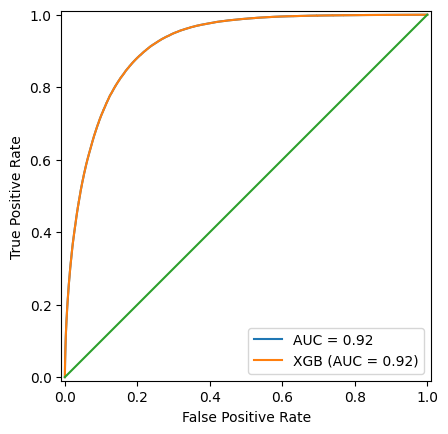

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Create figure with larger size and better styling
fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(train['Churn'], oof)
roc_auc = auc(fpr, tpr)

# Plot ROC curve with styling
display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, 
                          estimator_name='XGBoost')
display.plot(ax=ax, color='#2E86AB', lw=2.5, alpha=0.8)

# Plot diagonal line (random classifier)
plt.plot([0., 1.], [0., 1.], '--', color='#A23B72', lw=1.5, 
         label='Random Classifier (AUC = 0.5)', alpha=0.7)

# Customize the plot
ax.set_xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='semibold')
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='semibold')
ax.set_title('ROC Curve - Customer Churn Prediction', 
             fontsize=14, fontweight='bold', pad=20)

# Add grid for better readability
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Set axis limits with small padding
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])

# Add legend with better positioning
ax.legend(loc='lower right', framealpha=0.95, edgecolor='black')

# Add threshold annotations at specific points (optional)
threshold_indices = [0, len(thresholds)//4, len(thresholds)//2, 
                     3*len(thresholds)//4, -1]
threshold_points = [thresholds[i] for i in threshold_indices]

# Annotate some threshold points
for idx in threshold_indices[1:-1]:  # Skip first and last
    ax.annotate(f'Threshold: {thresholds[idx]:.2f}', 
                xy=(fpr[idx], tpr[idx]), 
                xytext=(10, 10), 
                textcoords='offset points',
                fontsize=9,
                bbox=dict(boxstyle='round,pad=0.3', 
                         facecolor='yellow', 
                         alpha=0.7),
                arrowprops=dict(arrowstyle='->', 
                               connectionstyle='arc3,rad=0.2', 
                               color='gray'))

# Add performance metrics text box
metrics_text = f'Model Performance Metrics:\n'
metrics_text += f'• AUC Score: {roc_auc:.4f}\n'
metrics_text += f'• Optimal Threshold: {thresholds[np.argmax(tpr - fpr)]:.3f}\n'
metrics_text += f'• Max Youden Index: {max(tpr - fpr):.4f}'

ax.text(0.62, 0.15, metrics_text,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment='top',
        bbox=dict(boxstyle='round', 
                 facecolor='lightblue', 
                 alpha=0.8,
                 edgecolor='navy'))

# Tight layout to prevent clipping
plt.tight_layout()

# Show the plot
plt.show()

# Print summary statistics
print(f"{'='*50}")
print(f"ROC-AUC Score: {roc_auc:.4f}")
print(f"{'='*50}")
print(f"Best threshold (Youden's J): {thresholds[np.argmax(tpr - fpr)]:.4f}")
print(f"At this threshold:")
print(f"  - TPR (Sensitivity): {tpr[np.argmax(tpr - fpr)]:.4f}")
print(f"  - FPR (1 - Specificity): {fpr[np.argmax(tpr - fpr)]:.4f}")
print(f"  - Youden's J: {max(tpr - fpr):.4f}")
print(f"{'='*50}")

In [23]:
print(f'\nIn total, we used {len(COLS)} features, Wow!\n')
print(list(COLS))


In total, we used 42 features, Wow!

['tenure', 'MonthlyCharges', 'TotalCharges', 'FREQ_tenure', 'FREQ_MonthlyCharges', 'FREQ_TotalCharges', 'TE1_CAT_tenure_std', 'TE1_CAT_MonthlyCharges_std', 'TE1_CAT_TotalCharges_std', 'TE1_gender_std', 'TE1_SeniorCitizen_std', 'TE1_Partner_std', 'TE1_Dependents_std', 'TE1_PhoneService_std', 'TE1_MultipleLines_std', 'TE1_InternetService_std', 'TE1_OnlineBackup_std', 'TE1_DeviceProtection_std', 'TE1_TechSupport_std', 'TE1_StreamingTV_std', 'TE1_StreamingMovies_std', 'TE1_Contract_std', 'TE1_PaperlessBilling_std', 'TE1_PaymentMethod_std', 'TE_CAT_tenure', 'TE_CAT_MonthlyCharges', 'TE_CAT_TotalCharges', 'TE_gender', 'TE_SeniorCitizen', 'TE_Partner', 'TE_Dependents', 'TE_PhoneService', 'TE_MultipleLines', 'TE_InternetService', 'TE_OnlineBackup', 'TE_DeviceProtection', 'TE_TechSupport', 'TE_StreamingTV', 'TE_StreamingMovies', 'TE_Contract', 'TE_PaperlessBilling', 'TE_PaymentMethod']


# XGB Feature Importance

In [24]:
feature_names = importances[0].keys()
importances_mean = [
    np.mean([imp[feat] if feat in imp else 0 for imp in importances])
    for feat in feature_names
]

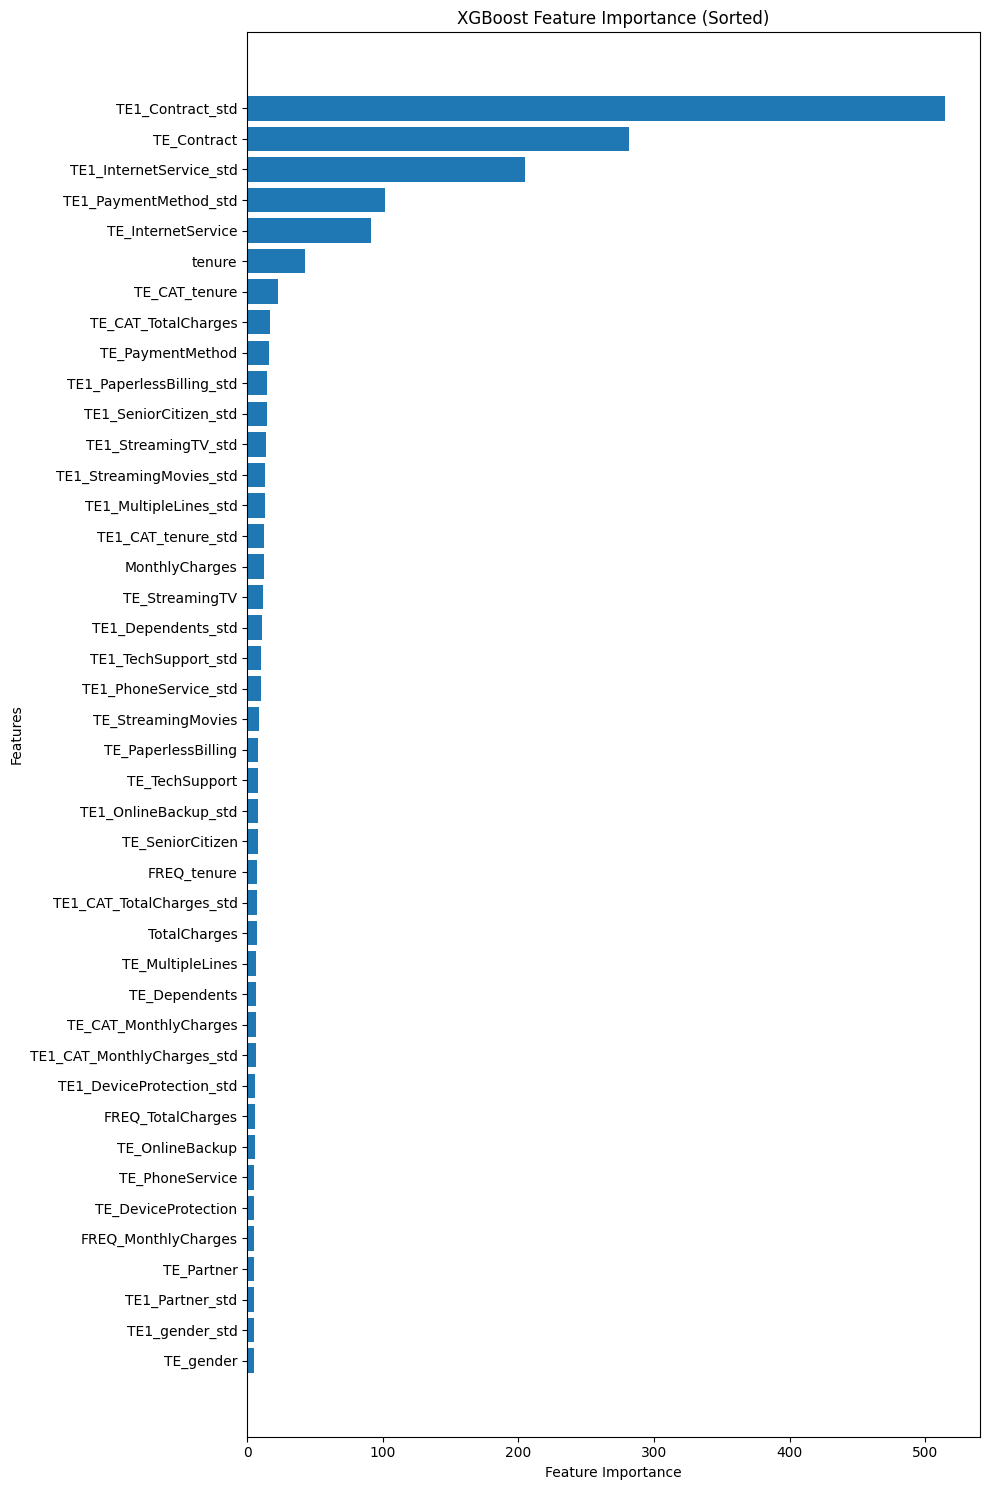

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Sort features by importance
indices = np.argsort(importances_mean)
sorted_features = np.array(list(feature_names))[indices]
sorted_importance = np.array(importances_mean)[indices]

# Create color gradient based on importance values
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(sorted_importance)))

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(12, max(8, len(sorted_features) * 0.4)))

# Plot horizontal bars with gradient colors
bars = ax.barh(range(len(sorted_importance)), sorted_importance, 
               color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

# Add value labels at the end of each bar
for i, (bar, val) in enumerate(zip(bars, sorted_importance)):
    ax.text(val + max(sorted_importance) * 0.01, bar.get_y() + bar.get_height()/2, 
            f'{val:.4f}', va='center', ha='left', fontsize=9, fontweight='bold')

# Customize y-axis with feature names
ax.set_yticks(range(len(sorted_features)))
ax.set_yticklabels(sorted_features, fontsize=10)

# Add labels and title
ax.set_xlabel('Feature Importance Score', fontsize=12, fontweight='semibold')
ax.set_ylabel('Features', fontsize=12, fontweight='semibold')
ax.set_title('XGBoost Feature Importance Analysis\n(Sorted by Impact on Churn Prediction)', 
             fontsize=14, fontweight='bold', pad=20)

# Add grid for better readability (only vertical lines)
ax.grid(True, axis='x', alpha=0.3, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)  # Grid behind bars

# Add cumulative importance line on secondary axis
cumulative_importance = np.cumsum(sorted_importance[::-1])[::-1] / np.sum(sorted_importance) * 100
ax2 = ax.twiny()
ax2.plot(cumulative_importance, range(len(sorted_importance)), 
         color='red', linewidth=2, linestyle='-', marker='o', markersize=4, alpha=0.7)
ax2.set_xlabel('Cumulative Importance (%)', fontsize=12, fontweight='semibold', color='red')
ax2.tick_params(axis='x', labelcolor='red')

# Add horizontal line at 80% cumulative importance
eighty_percent_idx = np.where(cumulative_importance >= 80)[0][-1]
ax2.axvline(x=80, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax2.text(82, eighty_percent_idx, '80% threshold', 
         color='red', fontsize=9, fontweight='bold')

# Highlight top features (top 5)
top_n = min(5, len(sorted_features))
for i in range(len(sorted_features) - top_n, len(sorted_features)):
    bars[i].set_edgecolor('gold')
    bars[i].set_linewidth(2)

# Add annotation for top features
ax.text(0.02, 0.98, f'🎯 Top {top_n} Features', 
        transform=ax.transAxes, fontsize=11, fontweight='bold',
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='gold', alpha=0.3, edgecolor='gold'))

# Add summary statistics box
stats_text = f'Feature Importance Summary:\n'
stats_text += f'• Total Features: {len(sorted_importance)}\n'
stats_text += f'• Mean Importance: {np.mean(sorted_importance):.4f}\n'
stats_text += f'• Std Deviation: {np.std(sorted_importance):.4f}\n'
stats_text += f'• Max Importance: {np.max(sorted_importance):.4f}\n'
stats_text += f'• Min Importance: {np.min(sorted_importance):.4f}\n'
stats_text += f'• Features for 80% cum. imp.: {eighty_percent_idx + 1}'

ax.text(0.02, 0.02, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8, edgecolor='navy'))

# Adjust layout and display
plt.tight_layout()
plt.show()

# Print detailed analysis
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)
print(f"\nTop {top_n} Most Important Features:")
print("-"*40)
for i in range(len(sorted_features) - top_n, len(sorted_features)):
    idx = len(sorted_features) - 1 - i
    print(f"{idx+1}. {sorted_features[i]}: {sorted_importance[i]:.6f}")

print(f"\nFeatures Contributing to 80% Cumulative Importance:")
print("-"*40)
for i in range(eighty_percent_idx, len(sorted_features)):
    print(f"• {sorted_features[i]}: {sorted_importance[i]:.6f}")

print(f"\nBottom {min(3, eighty_percent_idx)} Least Important Features:")
print("-"*40)
for i in range(min(3, eighty_percent_idx)):
    print(f"• {sorted_features[i]}: {sorted_importance[i]:.6f}")

# Create a DataFrame for reference
importance_df = pd.DataFrame({
    'Feature': sorted_features,
    'Importance': sorted_importance,
    'Cumulative_Importance_%': cumulative_importance
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("Complete Feature Importance Table:")
print("="*60)
print(importance_df.to_string(index=False))

In [26]:
dict(zip(feature_names, [float(f) for f in importances_mean]))

{'tenure': 42.27564010620117,
 'MonthlyCharges': 12.348388290405273,
 'TotalCharges': 7.039947509765625,
 'FREQ_tenure': 7.1544116020202635,
 'FREQ_MonthlyCharges': 5.06742115020752,
 'FREQ_TotalCharges': 5.41803674697876,
 'TE1_CAT_tenure_std': 12.406655311584473,
 'TE1_CAT_MonthlyCharges_std': 6.177778053283691,
 'TE1_CAT_TotalCharges_std': 7.083774566650391,
 'TE1_gender_std': 4.75553789138794,
 'TE1_SeniorCitizen_std': 14.199506759643555,
 'TE1_Partner_std': 4.938248062133789,
 'TE1_Dependents_std': 10.558748817443847,
 'TE1_PhoneService_std': 9.853453636169434,
 'TE1_MultipleLines_std': 12.95140438079834,
 'TE1_InternetService_std': 204.4489776611328,
 'TE1_OnlineBackup_std': 8.149772357940673,
 'TE1_DeviceProtection_std': 5.526635074615479,
 'TE1_TechSupport_std': 10.254302215576171,
 'TE1_StreamingTV_std': 13.674684524536133,
 'TE1_StreamingMovies_std': 13.403415107727051,
 'TE1_Contract_std': 514.6148803710937,
 'TE1_PaperlessBilling_std': 14.894267654418945,
 'TE1_PaymentMetho

# Save CSV

In [27]:
# SAVE OOF TO DISK FOR ENSEMBLES
df_oof = pd.DataFrame({'xgb': oof})
df_oof.to_csv(f'{NAME}_oof.csv', index=False)

df_test = pd.DataFrame({'xgb': pred})
df_test.to_csv(f'{NAME}_test.csv',index=False)

df_test = pd.DataFrame({f'fold_{i}': pred for (i, pred) in enumerate(pred_per_fold)})
df_test.to_csv(f'{NAME}_test_per_fold.csv', index=False)

print("Saved oof to file")

Saved oof to file


In [28]:
test.shape

(254655, 26)

In [29]:
sub = pd.DataFrame({
    'id': test['id'],
    'Churn': pred
})

sub.to_csv(f'{NAME}_submission.csv', index=False)

In [30]:
import pprint

In [31]:
# pprint.pprint(xgb_params)